## Visualization

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('heart.csv')

df.rename(columns = {
    'age' : 'Age',
    'sex' : 'Sex',
    'cp' : 'ChestPainType',
    'trestbps' : 'RestingBP',
    'chol' : 'Cholesterol',
    'fbs' : 'Fasting Blood Sugar',
    'restecg' : 'Resting ECG',
    'thalach' : 'Max Heart Rate',
    'exang' : 'Exercise Induced Angina',
    'oldpeak' : 'ST Depression',
    'slope' : 'Slope Of ST Segment',
    'ca' : 'Major Vessels Count',
    'thal' : 'Thalassemia',
    'target' : 'Heart Disease'
}, inplace = True)

df['Sex'] = df['Sex'].map({1: 'Male', 0: 'Female'})
df['Heart Disease'] = df['Heart Disease'].map({1: 'Has Heart Disease', 0: 'No Heart Disease'})
df['ChestPainType'] = df['ChestPainType'].map({0: 'Typical Angina', 1: 'Atypical Angina', 2: 'Non-Anginal Pain', 3: 'Asymptomatic'})
df['Fasting Blood Sugar'] = df['Fasting Blood Sugar'].map({1: 'High (>120mg/dl)', 0: 'Normal'})
df['Exercise Induced Angina'] = df['Exercise Induced Angina'].map({1: 'Yes', 0: 'No'})

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

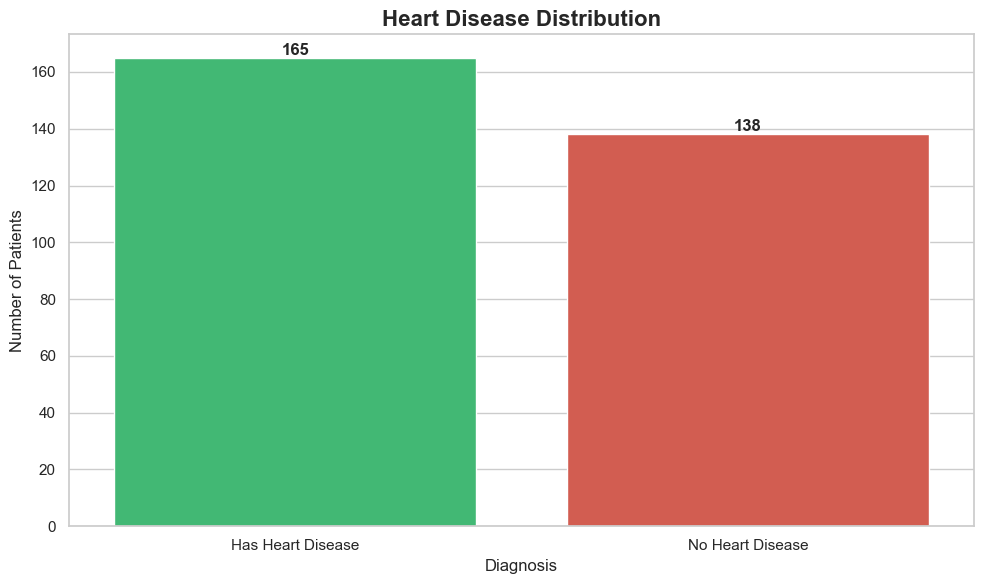

In [2]:
plt.figure()
ax = sns.countplot(x='Heart Disease', data=df, hue='Heart Disease',
                   palette= ['#2ecc71', '#e74c3c'], legend=False)

# add count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
plt.title('Heart Disease Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.tight_layout()
plt.savefig('chart1_distribution.png', dpi=150)
plt.show()

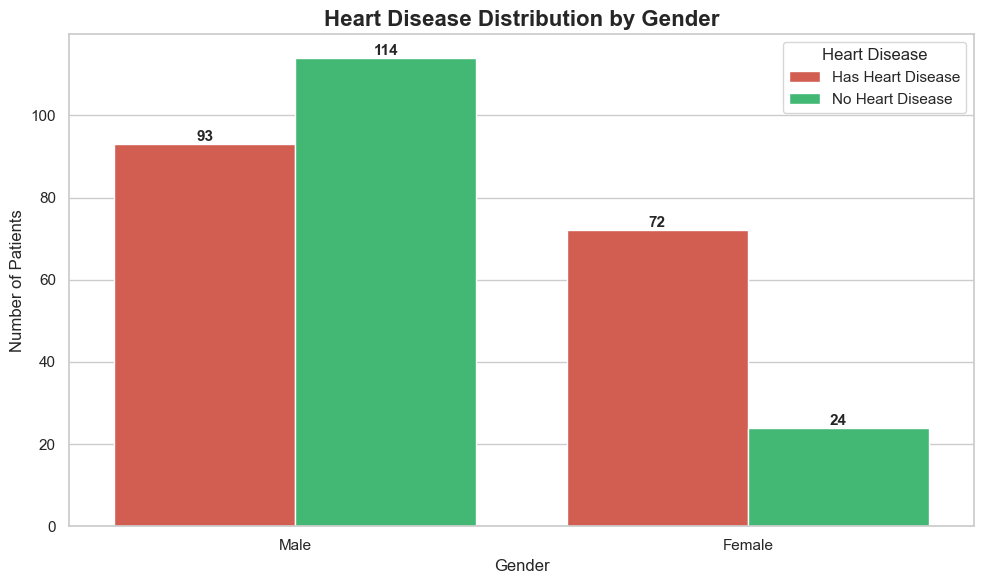

In [3]:
plt.figure()
ax = sns.countplot(x='Sex', data=df, hue='Heart Disease',
                   palette= {'Has Heart Disease': '#e74c3c', 'No Heart Disease': '#2ecc71'})

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    
plt.title('Heart Disease Distribution by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.tight_layout()
plt.savefig('chart2_gender.png', dpi=150)
plt.show()        

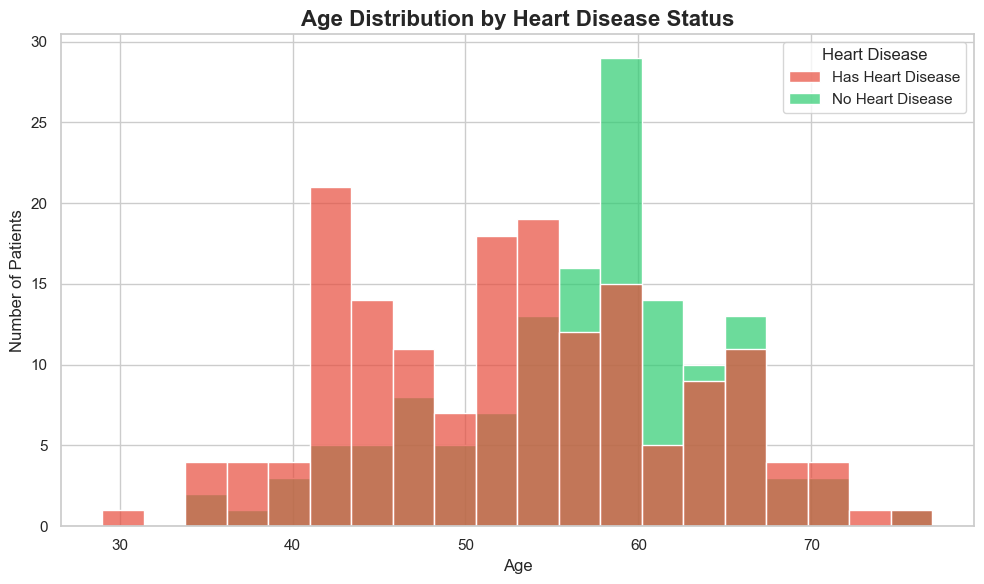

In [4]:
plt.figure()
sns.histplot(data=df, x='Age', hue='Heart Disease',
             palette= {'Has Heart Disease': '#e74c3c', 'No Heart Disease': '#2ecc71'},
             bins=20, alpha=0.7)
plt.title('Age Distribution by Heart Disease Status', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.tight_layout()
plt.savefig('chart3_age.png', dpi=150)
plt.show()

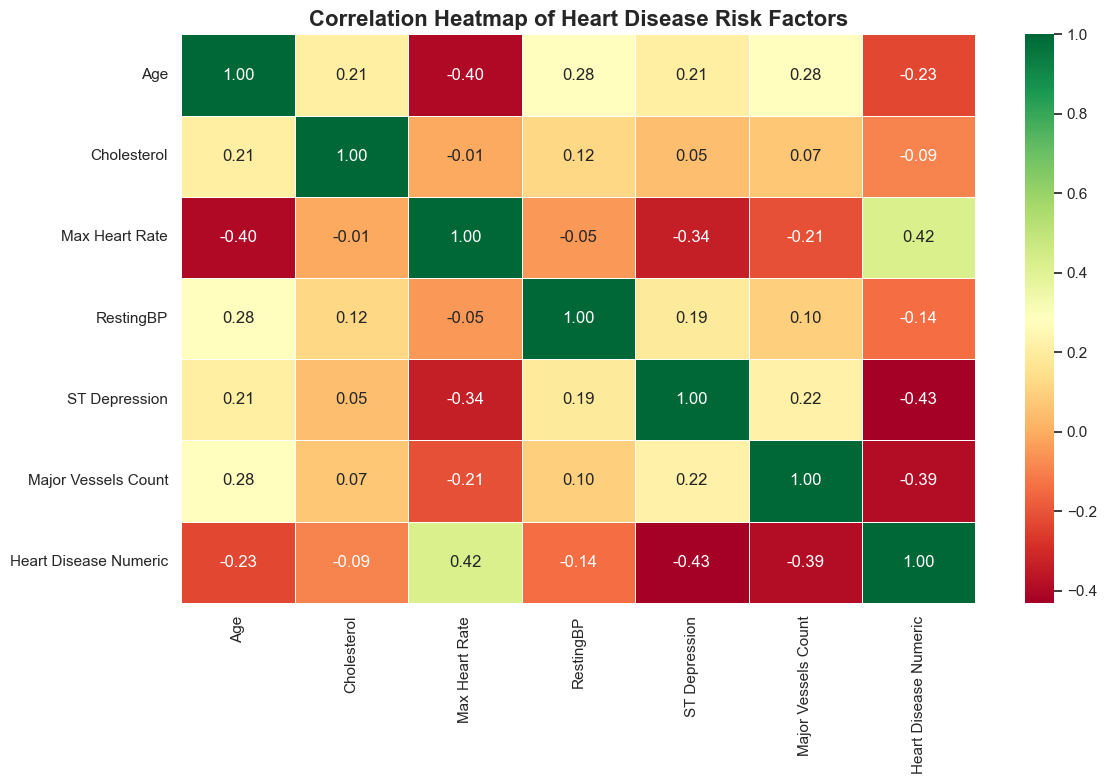

In [5]:
plt.figure(figsize=(12, 8))

df['Heart Disease Numeric'] = df['Heart Disease'].map({'Has Heart Disease': 1, 'No Heart Disease': 0})

# Select numeric columns only
numeric_df = df[['Age', 'Cholesterol', 'Max Heart Rate', 
                  'RestingBP', 'ST Depression', 'Major Vessels Count',
                  'Heart Disease Numeric']]

sns.heatmap(numeric_df.corr().round(2), 
            annot=True, 
            cmap='RdYlGn',
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Heatmap of Heart Disease Risk Factors', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150)
plt.show()

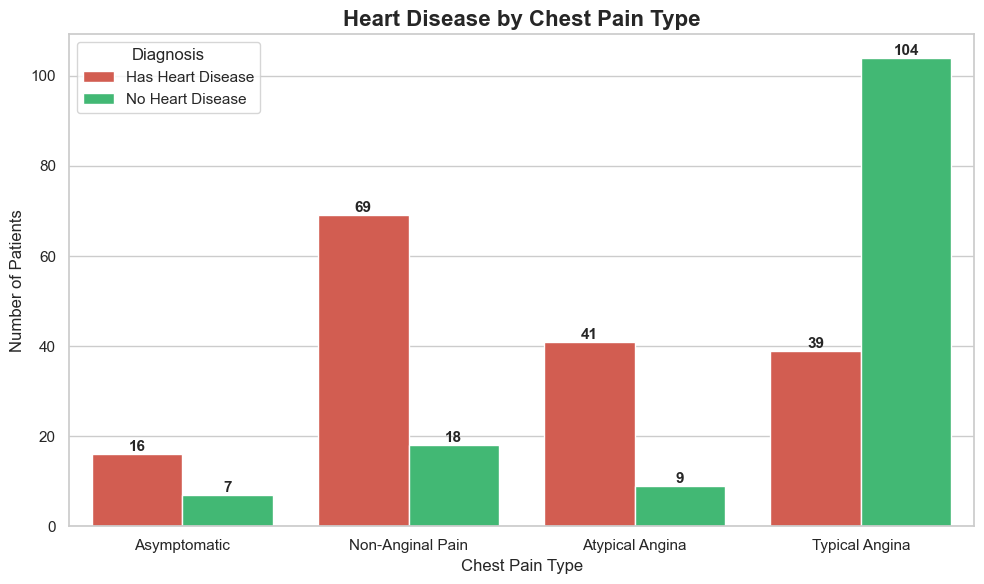

In [6]:
plt.figure()

ax = sns.countplot(x='ChestPainType', data=df,
              hue='Heart Disease',
              palette={'Has Heart Disease': '#e74c3c', 'No Heart Disease': '#2ecc71'})

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Heart Disease by Chest Pain Type', fontsize=16, fontweight='bold')
plt.xlabel('Chest Pain Type', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.savefig('chart5_chestpain.png', dpi=150)
plt.show()

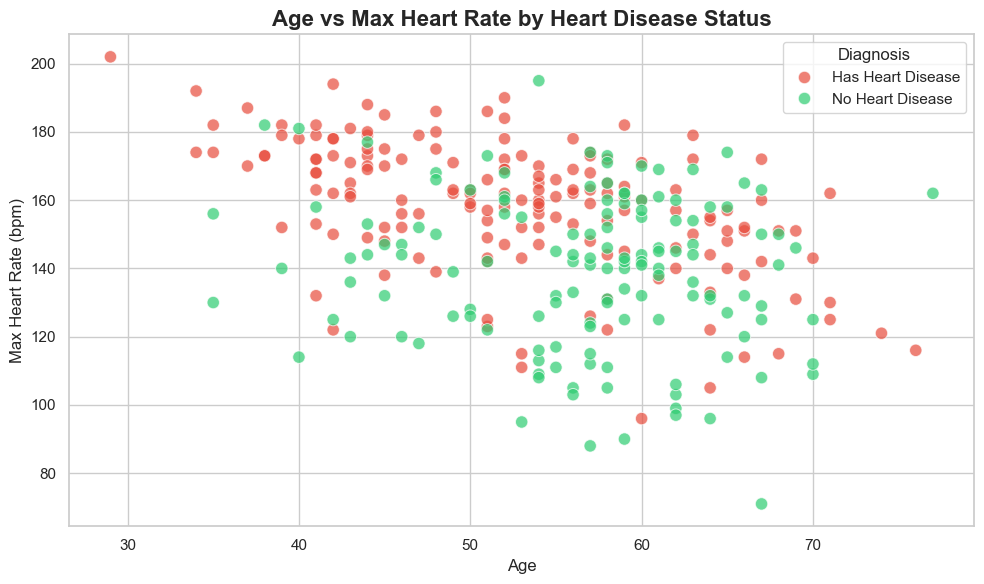

In [7]:
plt.figure()
sns.scatterplot(data=df, x='Age', y='Max Heart Rate',
                hue='Heart Disease',
                palette={'Has Heart Disease': '#e74c3c', 'No Heart Disease': '#2ecc71'},
                alpha=0.7, s=80)

plt.title('Age vs Max Heart Rate by Heart Disease Status', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Max Heart Rate (bpm)', fontsize=12)
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.savefig('chart6_scatter.png', dpi=150)
plt.show()